# Phase 1: Data Pipeline
## SVG Scaling Laws — CS-GY 6923 Optional Project

This notebook orchestrates all Phase 1 steps end-to-end:
1. Mount Google Drive & clone repo
2. Install dependencies
3. Run `01_download_data.py`
4. Run `02_clean_normalize.py`
5. Run `03_train_tokenizer.py`
6. Run `04_prepare_dataset.py`
7. Generate visualizations
8. Validate final dataset

**Expected runtime:** ~30-45 minutes (mostly data download + tokenization)

**Runtime recommendation:** GPU is not needed for Phase 1, but using Colab Pro is recommended for the RAM.

---
## Cell 0: Mount Google Drive
All outputs will be saved to Drive so they persist across Colab sessions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/svg-scaling-laws'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project dir: /content/drive/MyDrive/svg-scaling-laws


---
## Cell 1: Clone / Pull Repository
**Option A** (first time): Clone from GitHub  
**Option B** (resuming): Pull latest changes

Edit the repo URL below before running.

In [ ]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/svg-scaling-laws'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')
!ls

Repo already exists, pulling latest ...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 8 (delta 5), reused 8 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.34 KiB | 124.00 KiB/s, done.
From https://github.com/taahamohsin/ml-extra-credit-project
   0b62e32..5b56261  main       -> origin/main
Updating 0b62e32..5b56261
Fast-forward
 configs/data_config.yaml         |  1 +
 notebooks/01_data_pipeline.ipynb |  9 +++++++++
 scripts/03_train_tokenizer.py    | 14 +++++++++++---
 3 files changed, 21 insertions(+), 3 deletions(-)
Working directory: /content/svg-scaling-laws
configs    outputs		 README.md	   scripts
notebooks  PROJECT_BLUEPRINT.md  requirements.txt  src


---
## Cell 2: Install Dependencies

In [ ]:
# Install all requirements
!pip install -q -r requirements.txt

# cairosvg needs system libraries
!apt-get install -q -y libcairo2-dev libpango1.0-dev libgdk-pixbuf2.0-dev libffi-dev shared-mime-info
!pip install -q cairosvg

print('All dependencies installed.')

Reading package lists...
Building dependency tree...
Reading state information...
libffi-dev is already the newest version (3.4.2-4).
libffi-dev set to manually installed.
shared-mime-info is already the newest version (2.1-2).
shared-mime-info set to manually installed.
libcairo2-dev is already the newest version (1.16.0-5ubuntu2.1).
The following additional packages will be installed:
  libdatrie-dev libfribidi-dev libgdk-pixbuf-2.0-dev libgdk-pixbuf-xlib-2.0-0
  libgdk-pixbuf-xlib-2.0-dev libgdk-pixbuf2.0-bin libgraphite2-dev
  libharfbuzz-dev libharfbuzz-gobject0 libharfbuzz-icu0 libthai-dev
  pango1.0-tools
Suggested packages:
  libdatrie-doc libgraphite2-utils libpango1.0-doc libthai-doc graphicsmagick
The following NEW packages will be installed:
  libdatrie-dev libfribidi-dev libgdk-pixbuf-2.0-dev libgdk-pixbuf-xlib-2.0-0
  libgdk-pixbuf-xlib-2.0-dev libgdk-pixbuf2.0-bin libgdk-pixbuf2.0-dev
  libgraphite2-dev libharfbuzz-dev libharfbuzz-gobject0 libharfbuzz-icu0
  libpango1.0-

---
## Cell 3: Configure Output Paths
We symlink `outputs/` to Google Drive so everything persists.

In [ ]:
import os
import yaml

REPO_DIR = '/content/svg-scaling-laws'
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

# Create symlink from repo/outputs → Drive/outputs
if os.path.exists(LOCAL_OUTPUTS) and not os.path.islink(LOCAL_OUTPUTS):
    import shutil
    # Move any existing local outputs to Drive first
    if os.listdir(LOCAL_OUTPUTS):
        print('Moving existing local outputs to Drive ...')
        shutil.copytree(LOCAL_OUTPUTS, DRIVE_OUTPUTS, dirs_exist_ok=True)
    shutil.rmtree(LOCAL_OUTPUTS)

if not os.path.islink(LOCAL_OUTPUTS):
    os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
    print(f'Created symlink: {LOCAL_OUTPUTS} → {DRIVE_OUTPUTS}')
else:
    print(f'Symlink already exists: {LOCAL_OUTPUTS} → {os.readlink(LOCAL_OUTPUTS)}')

# Create required subdirectories
for subdir in ['data/raw', 'data/cleaned', 'data/binary', 'tokenizer',
               'checkpoints', 'logs', 'samples', 'plots', 'report']:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, subdir), exist_ok=True)

print('Directory structure ready.')
!ls {DRIVE_OUTPUTS}

Symlink already exists: /content/svg-scaling-laws/outputs → /content/drive/MyDrive/svg-scaling-laws/outputs
Directory structure ready.
checkpoints  data  logs  plots	report	samples  tokenizer


---
## Cell 4: Step 1 — Download Datasets
Downloads from HuggingFace. The primary dataset is `starvector/svg-icons-simple` (~89k SVGs).  
If we need more tokens to reach 100M, it automatically fetches supplementary datasets.

**Expected time:** 5-15 minutes (depends on HuggingFace bandwidth)

In [ ]:
import shutil, os

DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'

dirs_to_wipe = [
    'data/raw',
    'data/cleaned',
    'data/binary',
    'tokenizer',
]

print("Wiping cached intermediate outputs ...")
for d in dirs_to_wipe:
    full = os.path.join(DRIVE_OUTPUTS, d)
    if os.path.exists(full):
        shutil.rmtree(full)
        os.makedirs(full)
        print(f"  Cleared: {full}")
    else:
        os.makedirs(full, exist_ok=True)
        print(f"  Created: {full}")

print("\nAll intermediate outputs cleared. Ready for fresh run.")

Wiping cached intermediate outputs ...
  Cleared: /content/drive/MyDrive/svg-scaling-laws/outputs/data/raw
  Cleared: /content/drive/MyDrive/svg-scaling-laws/outputs/data/cleaned
  Cleared: /content/drive/MyDrive/svg-scaling-laws/outputs/data/binary
  Cleared: /content/drive/MyDrive/svg-scaling-laws/outputs/tokenizer

All intermediate outputs cleared. Ready for fresh run.


In [ ]:
!python scripts/01_download_data.py --config configs/data_config.yaml


Loading starvector/svg-icons-simple (split=train) ...
  Raw dataset size: 80,434 examples

[DEBUG] starvector/svg-icons-simple — column names: ['Filename', 'Svg']
[DEBUG] First example:
  'Filename': int = 78042
  'Svg': str = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.05937480926'
  Collected 80,434 SVG strings
  Saved 80,434 SVGs → /content/svg-scaling-laws/outputs/data/raw/icons_simple.jsonl

Estimated tokens from icons-simple: 7,962,966 (~99 tok/SVG)

Loading starvector/svg-emoji-simple (split=train) ...
  Raw dataset size: 4,114 examples

[DEBUG] starvector/svg-emoji-simple — column names: ['Filename', 'Svg']
[DEBUG] First example:
  'Filename': str = 'emoji_u1f44a_1f3fe-noto-emoji'
  'Svg': str = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-wi

In [ ]:
# Verify download
import json
manifest_path = 'outputs/data/raw/download_manifest.json'
with open(manifest_path) as f:
    manifest = json.load(f)
print('Download manifest:')
print(json.dumps(manifest, indent=2))

Download manifest:
{
  "downloaded_files": [
    "icons_simple.jsonl",
    "emoji_simple.jsonl",
    "fonts_simple.jsonl"
  ],
  "fonts_tokens": 112276692,
  "estimated_tokens_rough": 120646944,
  "target_tokens": 100000000,
  "note": "Actual token count computed after cleaning + tokenization in scripts 02-04"
}


---
## Cell 5: Step 2 — Clean & Normalize SVGs
Runs the 9-step cleaning pipeline on all downloaded SVGs.

**Expected time:** 5-10 minutes

In [ ]:
!python scripts/02_clean_normalize.py --config configs/data_config.yaml

Processing 3 raw file(s):
  /content/svg-scaling-laws/outputs/data/raw/icons_simple.jsonl
  /content/svg-scaling-laws/outputs/data/raw/emoji_simple.jsonl
  /content/svg-scaling-laws/outputs/data/raw/fonts_simple.jsonl

[DEBUG] XML validation spot-check (runs before any file processing):
  [PASS] good SVG: expected=True, got=True
  [PASS] unclosed tag: expected=False, got=False
  [PASS] mismatched tags: expected=False, got=False
  [PASS] unquoted attribute: expected=False, got=False
  All checks passed — lxml is correctly parsing XML.

Cleaning icons_simple.jsonl ...

[DEBUG] Sampling first 500 SVGs from icons_simple.jsonl ...

[DEBUG] Character lengths (raw, before cleaning):
  min=315, p5=1204, median=4260, max=20779
  SVGs below 50 chars: 0 / 500

[DEBUG] Deduplication (raw strings, before cleaning):
  Unique MD5 hashes: 500 / 500 (0.0% duplicates)

[DEBUG] 3 SVGs nearest to length threshold (50 chars):
  Example 1: raw_len=315
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.

In [ ]:
# Verify cleaning stats
with open('outputs/data/dataset_stats.json') as f:
    stats = json.load(f)

print('Cleaning statistics:')
print(f"  Total input SVGs:  {stats.get('total_input', '?'):>10,}")
print(f"  Total kept SVGs:   {stats.get('total_output', '?'):>10,}")
print(f"  Removed breakdown: {stats.get('removed', {})}")

# Count lines in cleaned.jsonl
import subprocess as sp
result = sp.run(['wc', '-l', 'outputs/data/cleaned/cleaned.jsonl'], capture_output=True, text=True)
print(f"\n  cleaned.jsonl lines: {result.stdout.strip()}")

Cleaning statistics:
  Total input SVGs:   1,218,656
  Total kept SVGs:    1,170,625
  Removed breakdown: {'no_svg_root': 0, 'invalid_xml': 0, 'too_short': 0, 'duplicate': 48031}

  cleaned.jsonl lines: 1170625 outputs/data/cleaned/cleaned.jsonl


---
## Cell 6: Step 3 — Train BPE Tokenizer
Trains a 4096-vocab BPE tokenizer on the cleaned SVG corpus.  
Also generates the token frequency distribution plot.

**Expected time:** 5-10 minutes

In [ ]:
!python scripts/03_train_tokenizer.py --config configs/data_config.yaml

Loading cleaned SVGs: 1170625it [00:11, 106353.12it/s]
Loaded 1,170,625 cleaned SVGs
Sampled 150,000 SVGs for tokenizer training (seed=42)

Training BPE tokenizer (vocab_size=4096) ...
  Saving locally to /tmp/tokenizer_local (Drive copy happens after stats)
Writing 150,000 SVGs to temp file for tokenizer training ...
Temp file: /tmp/tmpc_wb07mx.txt  (130.7 MB)
Training tokenizer from file ...
[00:00:27] Tokenize words                 ██████████████████ 348056   /   348056
[00:00:07] Count pairs                    ██████████████████ 348056   /   348056
[00:02:21] Compute merges                 ██████████████████ 3836     /     3836
Temp file deleted.
Tokenizer saved to /tmp/tokenizer_local/tokenizer.json
  Verified: 400.0 KB, valid JSON
Actual vocabulary size: 4,096

--- Example tokenizations ---

Example 1 (855 chars → 113 tokens):
  SVG (first 120 chars): '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black'
  Token


--- token_freq_distribution.png ---


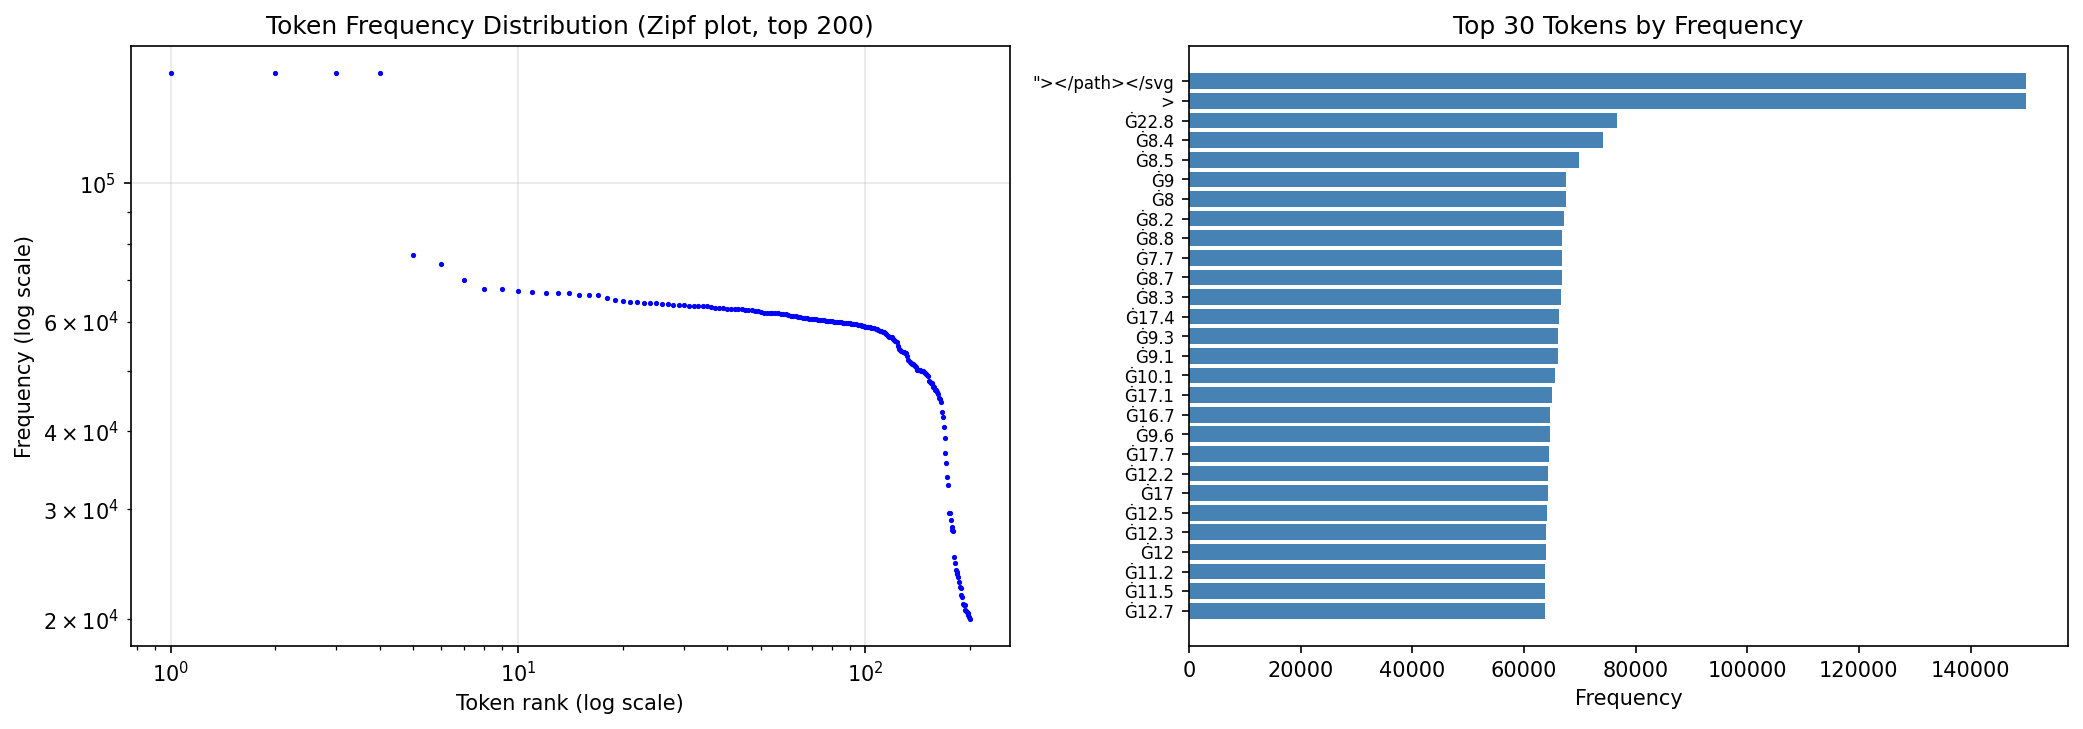


--- sequence_length_histogram.png ---


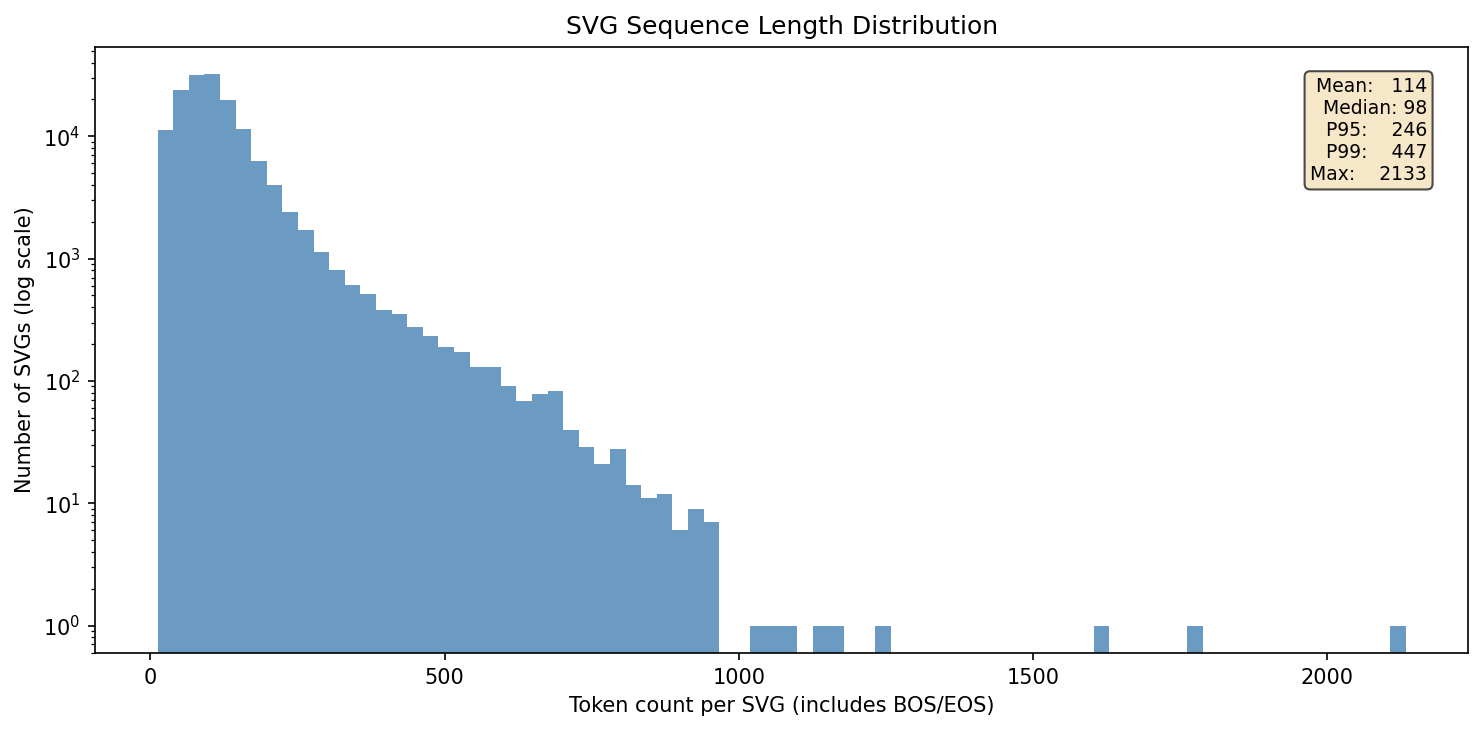

In [ ]:
# Display the generated plots
from IPython.display import Image, display
import os

for plot_name in ['token_freq_distribution.png', 'sequence_length_histogram.png']:
    plot_path = f'outputs/plots/{plot_name}'
    if os.path.exists(plot_path):
        print(f'\n--- {plot_name} ---')
        display(Image(plot_path))
    else:
        print(f'Plot not found: {plot_path}')

In [ ]:
# Show tokenizer stats
with open('outputs/tokenizer/tokenizer_stats.json') as f:
    tok_stats = json.load(f)

print(f"Vocabulary size: {tok_stats['vocab_size']}")
print(f"\nToken length statistics:")
ls = tok_stats['length_stats']
print(f"  Mean:    {ls['mean']:.1f} tokens")
print(f"  Median:  {ls['median']:.1f} tokens")
print(f"  P95:     {ls['p95']:.1f} tokens")
print(f"  P99:     {ls['p99']:.1f} tokens")
print(f"  Max:     {ls['max']} tokens")
print(f"  > 1024:  {ls['exceeds_max_length']} SVGs ({ls['exceeds_max_length_pct']:.1f}%)")

print(f"\nTop 10 tokens by frequency:")
for entry in tok_stats['top_30_tokens'][:10]:
    print(f"  id={entry['id']:>5}  {entry['token']:<30}  count={entry['count']:,}")

Vocabulary size: 4096

Token length statistics:
  Mean:    113.6 tokens
  Median:  98.0 tokens
  P95:     246.0 tokens
  P99:     447.0 tokens
  Max:     2133 tokens
  > 1024:  9 SVGs (0.0%)

Top 10 tokens by frequency:
  id=    1  <BOS>                           count=150,000
  id=  415  "></path></svg                  count=150,000
  id=   33  >                               count=150,000
  id=    2  <EOS>                           count=150,000
  id=  370  Ġ22.8                           count=76,593
  id=  489  Ġ8.4                            count=74,235
  id=  493  Ġ8.5                            count=69,902
  id=  291  Ġ9                              count=67,601
  id=  293  Ġ8                              count=67,544
  id=  527  Ġ8.2                            count=67,123


---
## Cell 7: Step 4 — Prepare Binary Dataset
Tokenizes all SVGs, applies length filter, splits 98/1/1 by file, and writes
train/val/test as numpy uint16 memmap files.

**Expected time:** 10-20 minutes

In [ ]:
!python scripts/04_prepare_dataset.py --config configs/data_config.yaml

Loading tokenizer ...
  Vocab size: 4,096
Loading cleaned SVGs: 1170625it [00:21, 55108.74it/s]

Total SVGs loaded: 1,170,625

Tokenizing and filtering (max_token_length=1024) ...
Tokenizing SVGs: 100% 1170625/1170625 [07:58<00:00, 2445.84it/s]
  Tokenized:  1,170,538
  Filtered (too long): 87 (0.0%)

Splitting train/val/test by file ...
  Train SVGs: 1,147,128
  Val SVGs:   11,705
  Test SVGs:  11,705

Writing binary files to local disk (/tmp/binary_local) ...
  train.bin: 130,404,653 tokens  (260.8 MB)
  val.bin:   1,326,073 tokens  (2.7 MB)
  test.bin:  1,341,361 tokens  (2.7 MB)

Verifying binary files ...
  All files verified OK.

Copying binary files to Drive (/content/svg-scaling-laws/outputs/data/binary) ...
  train.bin  (260.8 MB) → /content/svg-scaling-laws/outputs/data/binary/train.bin
  split_info.json  (0.0 MB) → /content/svg-scaling-laws/outputs/data/binary/split_info.json
  val.bin  (2.7 MB) → /content/svg-scaling-laws/outputs/data/binary/val.bin
  test.bin  (2.7 MB) → /

In [ ]:
# Verify binary outputs
import numpy as np

with open('outputs/data/binary/split_info.json') as f:
    split_info = json.load(f)

print('Split information:')
print(json.dumps(split_info, indent=2))

# Quick binary load check
print('\nVerifying binary files ...')
for split in ['train', 'val', 'test']:
    arr = np.memmap(f'outputs/data/binary/{split}.bin', dtype=np.uint16, mode='r')
    expected = split_info[f'{split}_tokens']
    status = '✓' if len(arr) == expected else f'✗ (got {len(arr)}, expected {expected})'
    size_mb = arr.nbytes / 1e6
    print(f"  {split:5s}.bin:  {len(arr):>12,} tokens  {size_mb:>8.1f} MB  {status}")

TARGET = 100_000_000
train_tokens = split_info['train_tokens']
check = '✓' if train_tokens >= TARGET else '✗ BELOW TARGET'
print(f'\nTraining tokens: {train_tokens:,}  {check}  (target: {TARGET:,})')

Split information:
{
  "train_svgs": 1147128,
  "val_svgs": 11705,
  "test_svgs": 11705,
  "train_tokens": 130404653,
  "val_tokens": 1326073,
  "test_tokens": 1341361,
  "total_tokens": 133072087,
  "max_token_length": 1024,
  "n_filtered_too_long": 87,
  "vocab_size": 4096,
  "dtype": "uint16",
  "bos_id": 1,
  "eos_id": 2,
  "seed": 42
}

Verifying binary files ...
  train.bin:   130,404,653 tokens     260.8 MB  ✓
  val  .bin:     1,326,073 tokens       2.7 MB  ✓
  test .bin:     1,341,361 tokens       2.7 MB  ✓

Training tokens: 130,404,653  ✓  (target: 100,000,000)


---
## Cell 8: Visualize Sample SVGs
Render 3 SVGs at different complexity levels (simple / medium / complex)  
to confirm the data looks correct.

In [ ]:
import json, io, os, random
import sys
sys.path.insert(0, '/content/svg-scaling-laws')

from src.tokenizer_utils import load_tokenizer, encode as tok_encode
from src.svg_utils import render_svg_to_png
from IPython.display import Image, display

tokenizer = load_tokenizer('outputs/tokenizer')

# Load all cleaned SVGs
all_svgs = []
with open('outputs/data/cleaned/cleaned.jsonl') as f:
    for line in f:
        if line.strip():
            all_svgs.append(json.loads(line)['svg'])

# Sample, compute token lengths, pick simple/medium/complex
random.seed(42)
sample = random.sample(all_svgs, min(5000, len(all_svgs)))
lengths = sorted([(len(tok_encode(tokenizer, s)), s) for s in sample], key=lambda x: x[0])
n = len(lengths)
examples = {
    'simple':  lengths[max(0, n // 20)],           # ~5th percentile (~50 tokens)
    'medium':  lengths[n // 2],                    # ~50th percentile (~200 tokens)
    'complex': lengths[min(n-1, int(n * 0.95))],   # ~95th percentile (~800 tokens)
}

plots_dir = 'outputs/plots'
os.makedirs(plots_dir, exist_ok=True)

for label, (n_tokens, svg) in examples.items():
    print(f'
=== {label.capitalize()} — {n_tokens} tokens, {len(svg)} chars ===')
    print('SVG code (first 400 chars):')
    print(svg[:400])
    print()
    png = render_svg_to_png(svg, output_size=256)
    if png:
        # Save to outputs/plots/ for the report
        img_path = os.path.join(plots_dir, f'sample_svg_{label}.png')
        with open(img_path, 'wb') as img_f:
            img_f.write(png)
        print(f'Rendered image saved to {img_path}')
        display(Image(data=png))
    else:
        print('(Rendering failed — cairosvg may not support this SVG)')

print('
Sample SVG renders complete. Images saved to outputs/plots/')


---
## Cell 9: Full Dataset Statistics Summary
Compile and display all Phase 1 statistics for the report.

In [ ]:
import json

with open('outputs/data/dataset_stats.json') as f:
    stats = json.load(f)

print('=' * 60)
print('PHASE 1 FINAL STATISTICS')
print('=' * 60)

print('\n--- Cleaning ---')
print(f"  Files input:          {stats.get('total_input', '?'):>10,}")
print(f"  Files kept:           {stats.get('total_output', '?'):>10,}")
removed = stats.get('removed', {})
for reason, count in removed.items():
    print(f"  Removed ({reason:<18}): {count:>6,}")

if 'tokenizer' in stats:
    print('\n--- Tokenizer ---')
    tok = stats['tokenizer']
    ls = tok['length_stats']
    print(f"  Vocabulary size:      {tok['vocab_size']:>10,}")
    print(f"  Mean seq length:      {ls['mean']:>10.1f} tokens")
    print(f"  Median seq length:    {ls['median']:>10.1f} tokens")
    print(f"  P95 seq length:       {ls['p95']:>10.1f} tokens")
    print(f"  P99 seq length:       {ls['p99']:>10.1f} tokens")

if 'splits' in stats:
    print('\n--- Splits ---')
    sp = stats['splits']
    print(f"  Train SVGs:           {sp['train_svgs']:>10,}")
    print(f"  Val SVGs:             {sp['val_svgs']:>10,}")
    print(f"  Test SVGs:            {sp['test_svgs']:>10,}")
    print(f"  Train tokens:         {sp['train_tokens']:>10,}")
    print(f"  Val tokens:           {sp['val_tokens']:>10,}")
    print(f"  Test tokens:          {sp['test_tokens']:>10,}")
    print(f"  Total tokens:         {sp['total_tokens']:>10,}")

TARGET = 100_000_000
train_tokens = stats.get('splits', {}).get('train_tokens', 0)
print(f"\n{'='*60}")
if train_tokens >= TARGET:
    print(f"✓ Training tokens: {train_tokens:,} (above 100M target)")
    print("Phase 1 COMPLETE. Proceed to Phase 2 (notebook 02_scaling_study.ipynb).")
else:
    print(f"✗ Training tokens: {train_tokens:,} (BELOW 100M target)")
    print("Need more data. See Section 4.1 of blueprint for supplementary datasets.")
print('=' * 60)

PHASE 1 FINAL STATISTICS

--- Cleaning ---
  Files input:           1,218,656
  Files kept:            1,170,625
  Removed (no_svg_root       ):      0
  Removed (invalid_xml       ):      0
  Removed (too_short         ):      0
  Removed (duplicate         ): 48,031

--- Tokenizer ---
  Vocabulary size:           4,096
  Mean seq length:           113.6 tokens
  Median seq length:          98.0 tokens
  P95 seq length:            246.0 tokens
  P99 seq length:            447.0 tokens

--- Splits ---
  Train SVGs:            1,147,128
  Val SVGs:                 11,705
  Test SVGs:                11,705
  Train tokens:         130,404,653
  Val tokens:            1,326,073
  Test tokens:           1,341,361
  Total tokens:         133,072,087

✓ Training tokens: 130,404,653 (above 100M target)
Phase 1 COMPLETE. Proceed to Phase 2 (notebook 02_scaling_study.ipynb).


---
## Cell 10: Save All Outputs to Drive
Since we symlinked `outputs/` to Drive, everything is already persisted.  
This cell just confirms what's saved.

In [ ]:
import os
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'

print('Files saved to Drive:')
for root, dirs, files in os.walk(DRIVE_OUTPUTS):
    # Skip huge binary files in listing
    dirs[:] = [d for d in dirs if d not in ['raw']]
    level = root.replace(DRIVE_OUTPUTS, '').count(os.sep)
    indent = ' ' * 2 * level
    folder = os.path.basename(root)
    print(f'{indent}{folder}/')
    for fname in files:
        fpath = os.path.join(root, fname)
        size = os.path.getsize(fpath)
        subindent = ' ' * 2 * (level + 1)
        if size > 1e6:
            print(f'{subindent}{fname}  ({size/1e6:.1f} MB)')
        else:
            print(f'{subindent}{fname}  ({size/1e3:.1f} KB)')

print('\nAll Phase 1 outputs are persisted to Google Drive.')
print('You can safely disconnect and resume in a new Colab session.')

---
## Done!

Phase 1 is complete. Here's what was produced:

| File | Purpose |
|------|---------|
| `outputs/data/raw/*.jsonl` | Raw SVGs from HuggingFace |
| `outputs/data/cleaned/cleaned.jsonl` | Cleaned SVGs (after 9-step pipeline) |
| `outputs/tokenizer/tokenizer.json` | Trained BPE tokenizer |
| `outputs/data/binary/train.bin` | Training tokens (uint16 memmap) |
| `outputs/data/binary/val.bin` | Validation tokens |
| `outputs/data/binary/test.bin` | Test tokens |
| `outputs/data/binary/split_info.json` | Split sizes and metadata |
| `outputs/data/dataset_stats.json` | Full pipeline statistics |
| `outputs/plots/token_freq_distribution.png` | Zipf plot for report |
| `outputs/plots/sequence_length_histogram.png` | Length distribution for report |

**Next:** Open `notebooks/02_scaling_study.ipynb` to run Phase 2 (model training).